# Régression linéaire et descente de gradient

CSI 4506 - automne 2026

Marcel Turcotte  
Version: août 9, 2026 11h48

# Préamble

## Message du jour

![](https://mobile-img.lpcdn.ca/v2/828x/r6b66/432e0a900b303952bad9004064bd64b9.jpg)

[L’Albanie nomme une ministre générée par l’intelligence
artificielle](https://www.lapresse.ca/international/europe/2025-09-12/lutte-contre-la-corruption/l-albanie-nomme-une-ministre-generee-par-l-intelligence-artificielle.php),
Agence France-Presse, La Presse, 2025-09-12.

L’Albanie a nommé un **ministre de l’IA**, Diella, au poste de ministre
des marchés publics. Bien que la nomination soit symbolique en raison
des exigences constitutionnelles, Diella vise à **éliminer la
corruption** dans les appels d’offres publics en utilisant l’IA pour des
processus plus rapides, plus efficaces et plus responsables.
L’initiative a suscité des réactions mitigées, certains la considérant
comme un coup de publicité, tandis que d’autres y voient un potentiel
d’amélioration de la transparence et de la confiance dans les marchés
publics.

## Résultats d’apprentissage

- **Différencier** les tâches de régression des tâches de
  classification.
- **Expliquer** la méthodologie pour l’entraînement des modèles de
  régression linéaire.
- **Interpréter** la fonction des algorithmes d’optimisation dans le
  traitement de la régression linéaire.
- **Détailler** l’importance des dérivées partielles dans l’*algorithme
  de descente de gradient*.
- **Comparer** les méthodes de descente de gradient **par lot**,
  **stochastique** et **mini-lot**.

Lors du cours précédent, nous avons examiné deux algorithmes
d’apprentissage distincts : les $k$ plus proches voisins (KNN) et les
arbres de décision, chacun utilisant des méthodes uniques pour
l’entraînement et la représentation des modèles. Le KNN n’implique pas
d’apprentissage explicite ; en revanche, les données elles-mêmes
constituent le modèle. Les arbres de décision, à l’inverse, utilisent un
algorithme glouton qui commence avec un arbre vide et l’ensemble complet
de données d’entraînement. L’algorithme ajoute progressivement des nœuds
de décision, en partitionnant l’ensemble de données parent en
sous-ensembles pour atteindre une plus grande homogénéité (ou pureté) au
sein de chaque classification résultante par rapport au nœud parent. Ce
processus récursif se termine lorsque les données d’un nœud satisfont
des critères d’arrêt prédéfinis, tels que l’obtention d’une classe
unique, l’atteinte d’un niveau de pureté minimum, ou l’atteinte d’une
profondeur d’arbre maximale. Une fois que l’arbre de décision est
construit, les données originales ne sont plus nécessaires. Ce cours
visait à démontrer que les modèles d’apprentissage supervisé peuvent
être représentés de diverses manières, chaque algorithme d’«
apprentissage » étant adapté à son modèle spécifique.

Dans le cours d’aujourd’hui, nous explorerons un algorithme
d’apprentissage applicable à une large gamme de modèles, y compris les
réseaux de neurones.

# Régression linéaire

## Justification

**La régression linéaire** est introduite pour présenter de manière
pratique un algorithme d’apprentissage bien connu, **la descente de
gradient**. De plus, elle sert de base pour introduire la **régression
logistique** – un algorithme de classification – qui facilite davantage
les discussions sur les **réseaux de neurones artificiels**.

- Régression linéaire
  - Descente de gradient
  - Régression logistique
    - Réseaux de neurones

De 2 à **2 billion** de paramètres!

Les algorithmes d’apprentissage pour les modèles d’apprentissage
automatique peuvent varier considérablement en fonction du modèle (par
exemple, arbres de décision, SVM, etc.). Afin de respecter notre emploi
du temps, nous nous concentrerons sur cette séquence spécifique.

Le concept de régression linéaire remonte aux premiers travaux de Sir
Francis Galton à la fin du 19ème siècle. Galton a introduit l’idée de
“régression” dans son article de 1886, qui portait sur la relation entre
la taille des parents et celle de leurs enfants. Il a observé que la
taille des enfants avait tendance à régresser vers la moyenne, ce qui a
conduit au terme “régression”.

Cependant, la formulation mathématique de la régression linéaire est
étroitement associée aux travaux de Karl Pearson, qui au début du 20ème
siècle a étendu les idées de Galton pour créer la méthode des moindres
carrés pour ajuster un modèle linéaire. La méthode elle-même, cependant,
a été développée plus tôt en 1805 par Adrien-Marie Legendre et
indépendamment par Carl Friedrich Gauss pour l’analyse de données
astronomiques.

**Voir :** Stanton (2001).

## Apprentissage supervisé - régression

- Les **données d’entraînement** sont une collection d’exemples
  **étiquetés**.
  - $\{(x_i,y_i)\}_{i=1}^N$
    - Chaque $x_i$ est un **vecteur d’attributs** avec $D$ dimensions.
    - $x_i^{(j)}$ est la valeur de l’**attribut** $j$ de l’exemple $i$,
      pour $j \in 1 \ldots D$ et $i \in 1 \ldots N$.
  - L’**étiquette** $y_i$ est un **nombre réel**.
- **Problème** : Étant donné l’ensemble de données en entrée, créer un
  **modèle** pouvant être utilisé pour prédire la valeur de $y$ pour un
  $x$ non vu.

Pouvez-vous penser à des exemples de tâches de régression ?

1.  **Prédiction du Prix de l’Habitation** :
    - **Application** : Estimation de la valeur marchande de propriétés
      résidentielles en fonction de attributs tels que l’emplacement, la
      taille, le nombre de chambres, l’âge et les commodités.
2.  **Prévision Boursière** :
    - **Application** : Prédire les prix futurs des actions ou des
      indices en se basant sur des données historiques, des indicateurs
      financiers et des variables économiques.
3.  **Prédiction Météorologique** :
    - **Application** : Estimer les températures futures, les
      précipitations et d’autres conditions météorologiques en utilisant
      des données historiques et des variables atmosphériques.
4.  **Prévision des Ventes** :
    - **Application** : Prédire les volumes de ventes futurs pour des
      produits ou services en analysant les données de ventes passées,
      les tendances du marché et les schémas saisonniers.
5.  **Prédiction de la Consommation Énergétique** :
    - **Application** : Prévoir la consommation énergétique future pour
      les ménages, les industries ou les villes en fonction des données
      historiques de consommation, des conditions météorologiques et des
      facteurs économiques.
6.  **Estimation des Coûts Médicaux** :
    - **Application** : Prédire les coûts de santé pour les patients en
      se basant sur leur historique médical, leurs informations
      démographiques et leurs plans de traitement.
7.  **Prédiction du Flux de Trafic** :
    - **Application** : Estimer les volumes de trafic futurs et les
      niveaux de congestion sur les routes et autoroutes en utilisant
      des données historiques de trafic et des entrées de capteurs en
      temps réel.
8.  **Estimation de la Valeur à Vie du Client (CLV)** :
    - **Application** : Prédire le revenu total qu’une entreprise peut
      attendre d’un client sur la durée de leur relation, basé sur le
      comportement d’achat et les données démographiques.
9.  **Prévision des Indicateurs Économiques** :
    - **Application** : Prédire les principaux indicateurs économiques
      tels que la croissance du PIB, les taux de chômage et l’inflation
      en utilisant des données économiques historiques et des tendances
      du marché.
10. **Prévision de la Demande** :
    - **Application** : Estimer la demande future pour des produits ou
      services dans divers secteurs comme le commerce de détail, la
      fabrication et la logistique pour optimiser la gestion des stocks
      et de la chaîne d’approvisionnement.
11. **Évaluation Immobilière** :
    - **Application** : Évaluer la valeur marchande de propriétés
      commerciales comme les immeubles de bureaux, les centres
      commerciaux et les espaces industriels en fonction de
      l’emplacement, de la taille et des conditions du marché.
12. **Évaluation du Risque d’Assurance** :
    - **Application** : Prédire le risque associé à l’assurance
      d’individus ou de propriétés, ce qui aide à déterminer les taux de
      primes, basé sur les données historiques de réclamations et les
      facteurs démographiques.
13. **Prédiction du Taux de Clics (CTR) des Annonces** :
    - **Application** : Estimer la probabilité qu’un utilisateur clique
      sur une annonce en ligne en fonction du comportement de
      l’utilisateur, des attributs de l’annonce et des facteurs
      contextuels.
14. **Prédiction du Défaut de Paiement de Prêt** :
    - **Application** : Prédire la probabilité qu’un emprunteur fasse
      défaut sur un prêt en fonction de l’historique de crédit, des
      revenus, du montant du prêt et d’autres indicateurs financiers.

En se concentrant sur les applications pouvant fonctionner sur un
appareil mobile.

1.  **Prédiction de la Durée de Vie de la Batterie** :
    - **Application** : Estimer la durée de vie restante de la batterie
      en fonction des habitudes d’utilisation, des applications en cours
      d’exécution et des paramètres de l’appareil.
2.  **Suivi de la Santé et de la Forme Physique** :
    - **Application** : Prédire la consommation de calories, la
      fréquence cardiaque ou la qualité du sommeil en fonction de
      l’activité de l’utilisateur, des données biométriques et de
      l’historique de santé.
3.  **Gestion des Finances Personnelles** :
    - **Application** : Prévoir les dépenses ou économies futures en
      fonction des habitudes de dépense, des modèles de revenus et des
      objectifs budgétaires.
4.  **Prévision Météorologique** :
    - **Application** : Fournir des prévisions météorologiques
      personnalisées basées sur la localisation actuelle et les données
      météorologiques historiques.
5.  **Estimation du Temps de Trajet et de Trafic** :
    - **Application** : Prédire les temps de trajet et suggérer des
      itinéraires optimaux en se basant sur les données historiques de
      trafic, les conditions en temps réel et le comportement de
      l’utilisateur.
6.  **Amélioration de la Qualité des Images et Vidéos** :
    - **Application** : Ajuster les paramètres de qualité d’image ou de
      vidéo (par exemple, luminosité, contraste) en fonction des
      conditions d’éclairage et des préférences de l’utilisateur.
7.  **Atteinte des Objectifs de Fitness** :
    - **Application** : Estimer le temps nécessaire pour atteindre des
      objectifs de fitness tels que la perte de poids ou le gain
      musculaire en fonction de l’activité de l’utilisateur et des
      apports alimentaires.
8.  **Optimisation des Performances des Appareils Mobiles** :
    - **Application** : Prédire les paramètres optimaux pour la
      performance de l’appareil et la durée de vie de la batterie en
      fonction des habitudes d’utilisation et de l’activité des
      applications.

## Éruptions du Old Faithful

In [1]:
import pandas as pd

WOLFRAM_CSV = "https://raw.githubusercontent.com/turcotte/csi4106-f25/refs/heads/main/datasets/old_faithful_eruptions/Sample-Data-Old-Faithful-Eruptions.csv"
df = pd.read_csv(WOLFRAM_CSV)

# Renommer les colonnes
df = df.rename(columns={"Duration": "eruptions", "WaitingTime": "waiting"})
print(df.shape)
df.head(6)

(272, 2)

**Attribution :** Wolfram Research, “Sample Data: Old Faithful
Eruptions” du Wolfram Data Repository (2016) [doi:
10.24097/wolfram.50727.data](https://doi.org/10.24097/wolfram.50727.data)

Le jeu de données utilisé dans cette présentation provient du Wolfram
Research Data Repository, avec sa publication initiale détaillée dans
Azzalini et Bowman (1990).

## Geyser Old Faithful

<https://youtu.be/Qxf3xzirBrs>

**Attribution :** Yellowstone National Park Trips

Old Faithful, situé dans le parc national de Yellowstone, est connu
comme le geyser le plus célèbre au monde. Il peut atteindre des hauteurs
d’éruption allant jusqu’à 140 pieds. Notamment, ses intervalles
d’éruption varient entre 60 et 110 minutes, en fonction de la durée de
l’éruption précédente.

## Visualisation Rapide

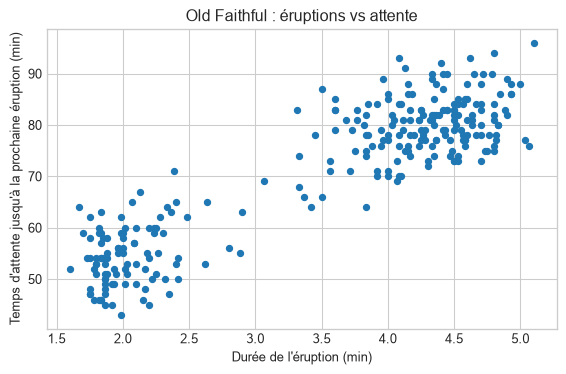

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df["eruptions"], df["waiting"], s=20)
plt.xlabel("Durée de l'éruption (min)")
plt.ylabel("Temps d'attente jusqu'à la prochaine éruption (min)")
plt.title("Old Faithful : éruptions vs attente")
plt.tight_layout()
plt.show()

La durée de l’éruption actuelle semble avoir une relation linéaire avec
le temps d’attente suivant : des durées d’éruption plus courtes tendent
à précéder des temps d’attente plus courts, tandis que des durées
d’éruption plus longues sont associées à des temps d’attente plus longs.

## Problème

- Prédire le **temps d’attente jusqu’à la prochaine éruption**, $y$, en
  fonction de la **durée de l’éruption actuelle**, $x$.

Choisir un problème caractérisé par un seul attribut nous permet de
mieux concentrer notre discussion et d’améliorer la clarté de la
visualisation.

------------------------------------------------------------------------

<https://youtu.be/qxo8p8PtFeA?si=Buy1DF-T1qPsVE2S>

## Régression linéaire

Un **modèle linéaire** suppose que la valeur de l’**étiquette**,
$\hat{y_i}$, peut être exprimée comme une **combinaison linéaire** des
valeurs des attributs, $x_i^{(j)}$ : $$
  \hat{y_i} = \theta_0 + \theta_1 x_i^{(1)} + \theta_2 x_i^{(2)} + \ldots + \theta_D x_i^{(D)}
$$

. . .

Ici, $\theta_{j}$ est le $j$-ième paramètre du **modèle** (linéaire),
avec $\theta_0$ étant le terme/paramètre de **biais**, et
$\theta_1 \ldots \theta_D$ étant les **poids des attributs**.

Dans mes présentations, j’utilise $\hat{y_i}$ et $h(x_i)$ de manière
synonyme.

Dans les contextes statistiques, la notation $\hat{y_i}$ est employée
pour désigner l’estimateur de la vraie valeur $y_i$. Cela représente le
résultat prédit ou estimé basé sur un modèle donné.

À l’inverse, en apprentissage automatique, on utilise la notation
$h(x_i)$, où $h$ représente la fonction d’hypothèse ou le modèle
appliqué aux données d’entrée $x_i$. La fonction d’hypothèse $h$ est
dérivée d’un espace d’hypothèses prédéfini, qui englobe l’ensemble de
tous les modèles possibles pouvant être utilisés pour mapper les données
d’entrée aux résultats prédits.

Le paramètre $\theta_0$ est appelé le **terme de biais** (aussi
“intercepte”) parce que :

- Il **décale la prédiction indépendamment des entrées**.
- Géométriquement, il déplace l’hyperplan de régression vers le haut ou
  vers le bas (ou à gauche/droite en classification), de sorte que le
  modèle n’est pas obligé de passer par l’origine.
- En termes d’apprentissage automatique, il agit comme un **décalage
  constant**, compensant les effets systématiques non expliqués par les
  attributs.

Ainsi, on l’appelle “biais” parce qu’il introduit une base fixe à
laquelle s’ajoutent les contributions des autres paramètres.

Dans un modèle d’apprentissage automatique, les **paramètres** sont les
**poids** et les **biais**.

## Définition

**Problème** : trouver les valeurs pour tous les paramètres du modèle de
sorte que le modèle **“s’ajuste au mieux”** aux données d’entraînement.

. . .

- L’**Erreur Quadratique Moyenne Racine** (*Root Mean Squared Error*
  \[RMSE\]) est une mesure de performance courante pour les problèmes de
  régression.

$$
    \sqrt{\frac{1}{N}\sum_1^N [h(x_i) - y_i]^2}
$$

Dans la mise en œuvre pratique, les algorithmes optimisent généralement
l’erreur quadratique moyenne (EQM) en raison de sa simplicité
mathématique et du fait qu’elle converge vers les mêmes estimations de
paramètres que d’autres mesures d’erreur. Bien que notre attention
actuelle soit portée sur l’utilisation de l’EQM, l’algorithme peut être
adapté pour fonctionner avec une gamme de fonctions objectives.

## Minimisation de l’EQM (RMSE)

![](https://upload.wikimedia.org/wikipedia/commons/thumb/b/b0/Linear_least_squares_example2.svg/2085px-Linear_least_squares_example2.svg.png)

**Attribution** :
[Krishnavedala](https://commons.wikimedia.org/wiki/File:Linear_least_squares_example2.svg),
[CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0), via
Wikimedia Commons

## Apprentissage

In [3]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Préparer les données
X = df[["eruptions"]].values  # shape (n_samples, 1)
y = df["waiting"].values      # shape (n_samples,)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ajuster via SGDRegressor — modèle linéaire via descente de gradient
sgd = SGDRegressor(
    loss="squared_error",
    penalty=None,
    learning_rate="constant",
    eta0=0.01,
    max_iter=2000,
    tol=None,
    random_state=42
)

sgd.fit(X_train, y_train)

print("Paramètres appris :")
print(f"  intercept = {sgd.intercept_[0]:.3f}")
print(f"  pente     = {sgd.coef_[0]:.3f}")

y_pred = sgd.predict(X_test)
print(f"MSE test = {mean_squared_error(y_test, y_pred):.2f}")
print(f"R² test  = {r2_score(y_test, y_pred):.3f}")

Paramètres appris :
  intercept = 32.910
  pente     = 10.503
MSE test = 43.02
R² test  = 0.671

## Visualisation

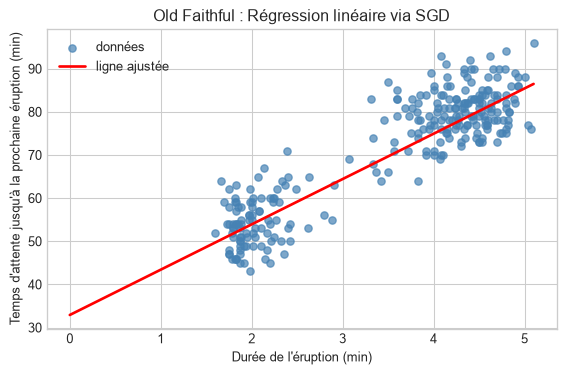

In [4]:
import numpy as np

# Disperser les données
plt.figure(figsize=(6,4))
plt.scatter(X, y, color="steelblue", s=30, alpha=0.7, label="données")

# Tracer la ligne ajustée
x_line = np.linspace(0, X.max(), 100).reshape(-1, 1)
y_line = sgd.predict(x_line)
plt.plot(x_line, y_line, color="red", linewidth=2, label="ligne ajustée")

plt.xlabel("Durée de l'éruption (min)")
plt.ylabel("Temps d'attente jusqu'à la prochaine éruption (min)")
plt.title("Old Faithful : Régression linéaire via SGD")
plt.legend()
plt.tight_layout()
plt.show()

Dans le graphique ci-dessus, la ligne $x=0$ est incluse pour faciliter
la visualisation de l’intercept, qui est donné par $\theta_0 = 32.910$.

## Caractéristiques

Un **algorithme d’apprentissage** typique comprend les composants
suivants :

1.  Un **modèle**, souvent composé d’un ensemble de **paramètres** dont
    les valeurs seront **“apprises”**.
2.  Une **fonction objectif**.
    - Dans le cas de la **régression**, il s’agit souvent d’une
      **fonction de perte** (*loss function*), une fonction qui
      quantifie la mauvaise classification. L’**Erreur Quadratique
      Moyenne Racine** est une fonction de perte courante pour les
      problèmes de régression.
      $\sqrt{\frac{1}{N}\sum_1^N [h(x_i) - y_i]^2}$
3.  Un **algorithme d’optimisation**

## Optimisation

**Jusqu’à** ce que certains critères d’arrêt soient atteints[1] :

- **Évaluer** la fonction de perte, en comparant $h(x_i)$ à $y_i$.
- **Apporter de petites modifications aux poids**, de manière à réduire
  la valeur de la fonction de perte.

## Remarques

- Il est important de séparer l’**algorithme d’optimisation** du
  **problème** qu’il traite.
- Pour la **régression linéaire**, une solution analytique exacte
  existe, mais elle présente certaines limitations.
- La **descente de gradient** sert d’algorithme général applicable non
  seulement à la régression linéaire, mais aussi à la régression
  logistique, l’apprentissage profond, t-SNE (t-distributed Stochastic
  Neighbor Embedding), parmi divers autres problèmes.
- Il existe une gamme diversifiée d’algorithmes d’optimisation qui **ne
  reposent pas sur des méthodes basées sur le gradient**.

## Optimisation — un attribut

- **Modèle** (hypothèse) :  
  $$
   h(x_i; \theta) = \theta_0 + \theta_1 x_i^{(1)}
  $$

- **Fonction de perte/coût** :  
  $$
   J(\theta_0, \theta_1) = \frac{1}{N}\sum_{i=1}^N [h(x_i;\theta) - y_i]^2
  $$

**Objectif** : trouver $\theta_0, \theta_1$ qui minimisent $J$, en
mettant à jour les paramètres de manière itérative.

Cet écran est primordial pour notre présentation, et il est essentiel de
bien comprendre son contenu, car il provoque souvent de la confusion.

En apprentissage automatique, un algorithme génère un modèle, noté $h$.
Ce modèle est dérivé des données d’entraînement, représentées par $X$.
Une fois le modèle entraîné, il peut être utilisé pour prédire les
résultats de nouvelles données non vues, notées $x_{\mathrm{new}}$. Une
fois entraînés, les paramètres du modèle, $\theta$, deviennent fixes. Le
modèle fonctionne en mappant chaque entrée $x_i$ à une sortie prédite
$\hat{y}_i$, $x_i \mapsto \hat{y}_i$.

La fonction de coût est utilisée pour déterminer les valeurs optimales
des paramètres, $\theta$, pour le modèle $h$. Sur cet écran, la perte
est spécifiée comme l’erreur quadratique moyenne. Notre objectif est
d’identifier $\theta$ de sorte que le modèle $h$ minimise son erreur sur
le jeu de données d’entraînement $X$. La fonction de perte mappe la
paire de paramètres $(\theta_0, \theta_1)$ à un nombre réel non négatif
$\mathbb{R}_{\ge0}$, $(\theta_0,\theta_1)\mapsto\mathbb{R}_{\ge0}$, qui
agrège les erreurs sur tous les points de données.

La descente de gradient est un processus qui opère dans l’espace des
paramètres, où elle ajuste $\theta$ pour minimiser la perte, plutôt que
dans l’espace des attributs des données.

La notation $h(x_i; \theta)$ indique que la valeur de la fonction $h$
(du modèle) dépend de l’exemple en entrée $x_i$ ainsi que des paramètres
$\theta$. Le point-virgule sert à différencier de manière sémantique ces
deux ensembles de valeurs. Cette convention est issue du domaine des
statistiques. En apprentissage automatique, on emploie également la
notation $h_{\theta}(x_i)$, qui peut être considérée comme plus
appropriée. Dans ce contexte, on parle d’une famille indexée de
fonctions, où $\theta$ détermine spécifiquement quelle fonction
$h_\theta$ doit être utilisée. Cette notation se lit comme suit : « la
fonction $h$, paramétrée par $\theta$, appliquée à l’entrée $x_i$. »

## Hypothèses vs paramètres

[1] Par exemple, la valeur de la **fonction de perte ne diminue plus**
ou le **nombre maximal d’itérations**.

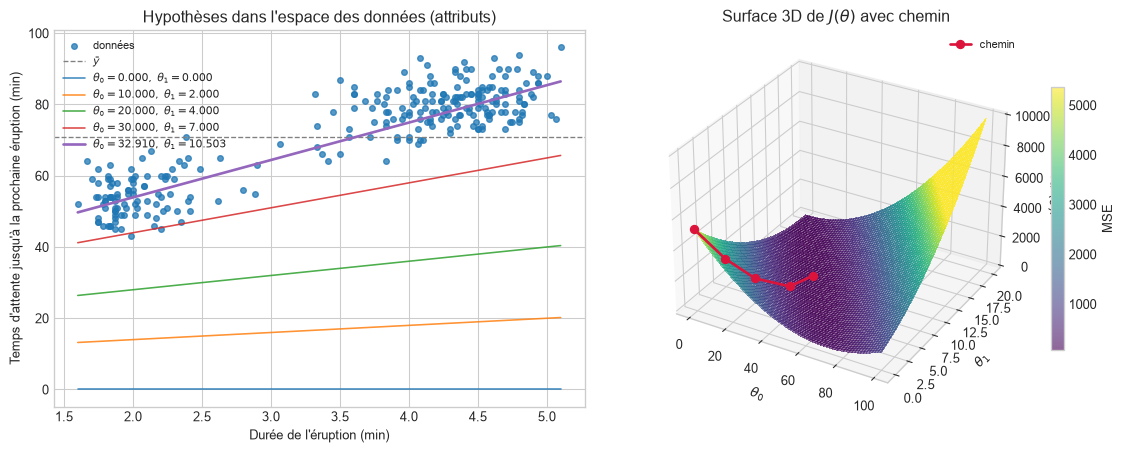

Dans cet exemple, nous utilisons le jeu de données des éruptions du
geyser Old Faithful.

La figure de gauche illustre les données dans leur espace de attributs,
où chaque droite représente une hypothèse distincte. Par exemple, la
droite bleue horizontale correspond à l’hypothèse définie par les
paramètres $(\theta_0=0, \theta_1=0)$, tandis que la droite orange
correspond à $(\theta_0=10, \theta_1=2)$. La séquence des paramètres du
modèle, ou hypothèses, a été délibérément conçue pour élucider les
concepts sous-jacents.

Inversement, la figure de droite représente l’espace des paramètres, où
l’optimisation est effectuée. Dans cet espace, l’axe vertical indique
l’erreur quadratique moyenne (MSE) pour toutes les combinaisons de
$\theta_0$ et $\theta_1$. Plus spécifiquement, un modèle caractérisé par
ces paramètres engendrerait ce niveau d’erreur avec les données
d’entraînement spécifiées. Pendant le processus d’entraînement, les
données restent constantes, tandis que les paramètres $\theta_0$ et
$\theta_1$ sont ajustés pour minimiser l’erreur.

Dans la figure de droite, la progression des paramètres du modèle, notée
($\theta_0, \theta_1$) avec la séquence
$\{(0.000, 0.000), (10.000, 2.000), (20.000, 4.000), (30.000, 7.000), (32.910, 10.503)\}$,
illustre une réduction de l’erreur quadratique moyenne (MSE),
$J(\theta)$.

## Hypothèses vs paramètres

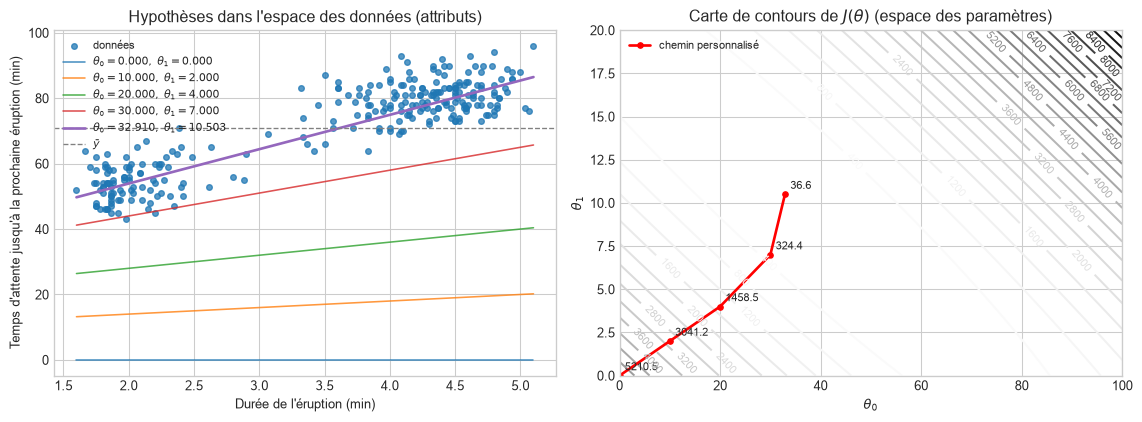

Ces figures illustrent le même concept, mais en utilisant un graphique
de contours.

# Dérivée

## Dérivée

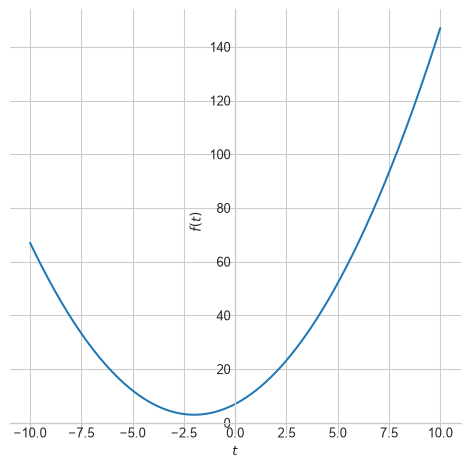

- Nous commencerons par une **fonction à une variable**.
- Considérez cela comme notre **fonction de perte**, que nous visons à
  minimiser; pour réduire la disparité moyenne entre les valeurs
  attendues et les valeurs prédites.
- J’utilise le symbol $t$ pour la variable afin d’éviter toute confusion
  avec les attributs des exemples de notre jeu de données.

## Code source

In [8]:
from sympy import *

t = symbols('t')

f = t**2 + 4*t + 7

plot(f)

Sur l’écran précédent, j’ai utilisé [**SymPy**](https://www.sympy.org/),
une bibliothèque pour les **mathématiques symboliques**.

## Dérivée

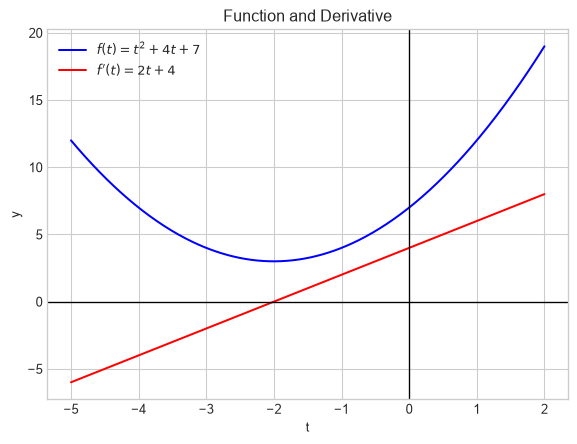

- Le graphe de la **dérivée**, $f^{'}(t)$, est représenté en **rouge**.

- La **dérivée** indique comment les changements dans l’entrée affectent
  la sortie, $f(t)$.

- La magnitude de la **dérivée** en $t = -2$ est $0$.

- Ce point correspond au **minimum** de notre fonction.

Près de $t = -2$, les variations de $t$ ont un impact minimal sur la
variable de sortie $y$.

## Dérivée

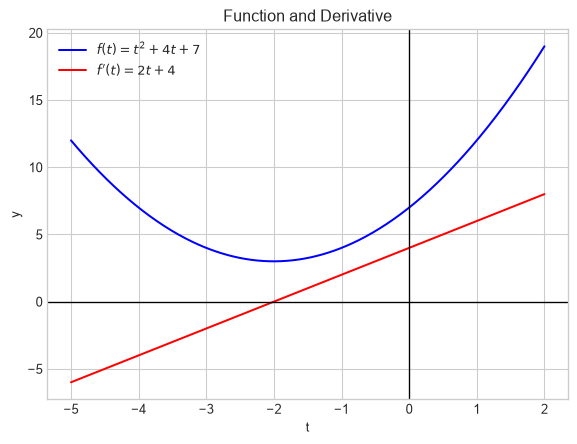

- Lorsqu’elle est évaluée en un **point spécifique**, la dérivée indique
  la **pente** de la **ligne tangente** au graphe de la fonction à ce
  point.

- À $t= -2$, la **pente** de la **ligne tangente** est de 0.

## Dérivée

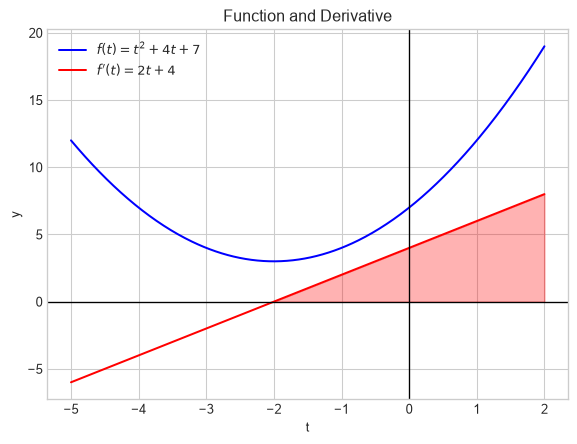

- Une **dérivée positive** indique qu’**augmenter la variable d’entrée**
  entraînera une **augmentation de la valeur de sortie**.

- De plus, la **magnitude** de la dérivée quantifie la **rapidité** du
  changement de la sortie.

## Dérivée

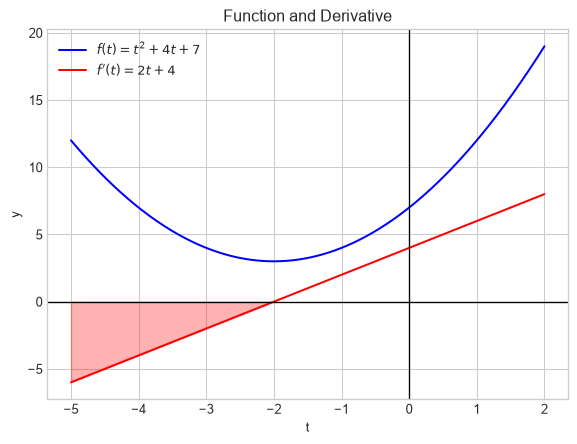

- Une **dérivée négative** indique qu’**augmenter la variable d’entrée**
  entraînera une **diminution de la valeur de sortie**.

- De plus, la **magnitude** de la dérivée quantifie la **rapidité** du
  changement de la sortie.

## Code source

In [13]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Define the variable and function
t = sp.symbols('t')
f = t**2 + 4*t + 7

# Compute the derivative
f_prime = sp.diff(f, t)

# Lambdify the functions for numerical plotting
f_func = sp.lambdify(t, f, "numpy")
f_prime_func = sp.lambdify(t, f_prime, "numpy")

# Generate t values for plotting
t_vals = np.linspace(-5, 2, 400)

# Get y values for the function and its derivative
f_vals = f_func(t_vals)
f_prime_vals = f_prime_func(t_vals)

# Plot the function and its derivative
plt.plot(t_vals, f_vals, label=r'$f(t) = t^2 + 4t + 7$', color='blue')
plt.plot(t_vals, f_prime_vals, label=r"$f'(t) = 2t + 4$", color='red')

# Fill the area below the derivative where it's negative
plt.fill_between(t_vals, f_prime_vals, where=(f_prime_vals > 0), color='red', alpha=0.3)

# Add labels and legend
plt.axhline(0, color='black',linewidth=1)
plt.axvline(0, color='black',linewidth=1)
plt.title('Function and Derivative')
plt.tlabel('t')
plt.ylabel('y')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

# Descente de gradient

## Descente de gradient — un attribut

- **Modèle** (hypothèse) :  
  $$
   h(x_i; \theta) = \theta_0 + \theta_1 x_i^{(1)}
  $$

- **Fonction de perte/coût** :  
  $$
   J(\theta_0, \theta_1) = \frac{1}{N}\sum_{i=1}^N [h(x_i;\theta) - y_i]^2
  $$

## Descente de gradient - intuition

<https://youtu.be/i62czvwDlsw>

## Descente de gradient - étape par étape

<https://www.youtube.com/watch?v=sDv4f4s2SB8>

## Descente de gradient - une variable

- **Initialisation :** $\theta_0$ et $\theta_1$ - soit avec des valeurs
  aléatoires, soit avec des zéros.
- **Boucle :**
- répéter jusqu’à convergence : $$
  \theta_j := \theta_j - \alpha \frac {\partial}{\partial \theta_j}J(\theta_0, \theta_1) , \text{pour } j=0 \text{ et } j=1
  $$
- $\alpha$ est appelé le **taux d’apprentissage** - c’est la taille de
  chaque pas.
- $\frac {\partial}{\partial \theta_j}J(\theta_0, \theta_1)$ est la
  **dérivée partielle** par rapport à $\theta_j$.

Une **dérivée partielle** représente le taux de changement d’une
fonction multivariable **par rapport à l’une de ses variables**, tout en
**gardant les autres variables constantes**.

Pour que l’algorithme soit mathématiquement valide, tous les $\theta_j$
doivent être mis à jour **simultanément**.

Dans le domaine de l’apprentissage automatique, un taux d’apprentissage
($\alpha$) couramment utilisé est de $10^{-3}$.

## Descente de gradient - une variable

``` python
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Définir la variable et la fonction
t = sp.symbols('t')
f = t**2 + 4*t + 7

# Calculer la dérivée
f_prime = sp.diff(f, t)

# Lambdifier les fonctions pour le traçage numérique
f_func = sp.lambdify(t, f, "numpy")
f_prime_func = sp.lambdify(t, f_prime, "numpy")

# Générer des valeurs de t pour le traçage
t_vals = np.linspace(-5, 2, 400)

# Obtenir des valeurs y pour la fonction et sa dérivée
f_vals = f_func(t_vals)
f_prime_vals = f_prime_func(t_vals)

# Tracer la fonction et sa dérivée
plt.plot(t_vals, f_vals, label=r'$J$', color='blue')
plt.plot(t_vals, f_prime_vals, label=r"$\frac {\partial}{\partial \theta_j}J(\theta)$", color='red')

# Ajouter des étiquettes et une légende
plt.axhline(0, color='black',linewidth=1)
plt.axvline(0, color='black',linewidth=1)
plt.title('Fonction et Dérivée')
plt.xlabel(r'$\theta_j$')
plt.ylabel(r'$J$')
plt.legend()

# Afficher le graphique
plt.grid(True)
plt.show()
```

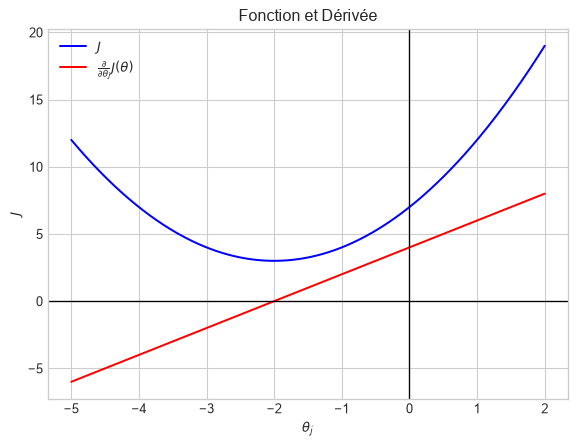

- Lorsque la valeur de $\theta_j$ est dans l’intervalle $[- \inf, -2)$,
  $\frac {\partial}{\partial \theta_j}J(\theta)$ a une valeur
  **négative**.

- Par conséquent,
  $- \alpha \frac {\partial}{\partial \theta_j}J(\theta)$ est
  **positif**.

- En conséquence, la valeur de $\theta_j$ est **augmentée**.

Règle de mise à jour :
$\theta_j := \theta_j - \alpha \frac {\partial}{\partial \theta_j}J(\theta_0, \theta_1) , \text{pour } j=0 \text{ et } j=1$.

## Descente de gradient - une variable

``` python
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Définir la variable et la fonction

t = sp.symbols('t')
f = t**2 + 4*t + 7

# Calculer la dérivée

f_prime = sp.diff(f, t)

# Lambdifier les fonctions pour le tracé numérique

f_func = sp.lambdify(t, f, "numpy")
f_prime_func = sp.lambdify(t, f_prime, "numpy")

# Générer les valeurs de t pour le traçage

t_vals = np.linspace(-5, 2, 400)

# Obtenir les valeurs y pour la fonction et sa dérivée

f_vals = f_func(t_vals)
f_prime_vals = f_prime_func(t_vals)

# Tracer la fonction et sa dérivée

plt.plot(t_vals, f_vals, label=r'$J$', color='blue')
plt.plot(t_vals, f_prime_vals, label=r"$\frac {\partial}{\partial \theta_j}J(\theta)$", color='red')

# Ajouter des étiquettes et une légende

plt.axhline(0, color='black',linewidth=1)
plt.axvline(0, color='black',linewidth=1)
plt.title('Fonction et Dérivée')
plt.xlabel(r'$\theta_j$')
plt.ylabel(r'$J$')
plt.legend()

# Afficher le graphique

plt.grid(True)
plt.show()
```

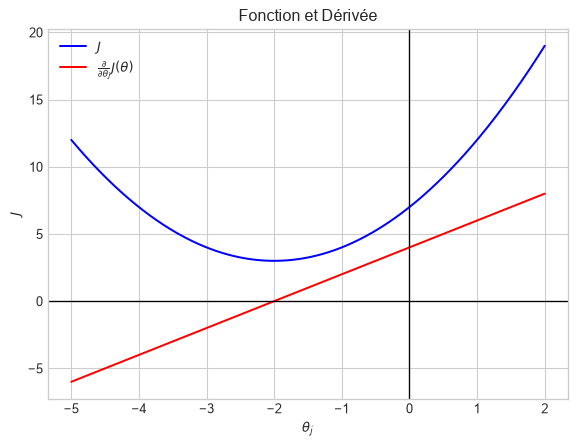

- Lorsque la valeur de $\theta_j$ est dans l’intervalle $(-2, \infty]$,
  $\frac {\partial}{\partial \theta_j}J(\theta)$ a une valeur
  **positive**.

- Par conséquent,
  $- \alpha \frac {\partial}{\partial \theta_j}J(\theta)$ est
  **négatif**.

- En conséquence, la valeur de $\theta_j$ est **diminuée**.

Règle de mise à jour:
$\theta_j := \theta_j - \alpha \frac {\partial}{\partial \theta_j}J(\theta_0, \theta_1) , \text{pour } j=0 \text{ et } j=1$.

## Dérivées partielles

Étant donnée

$$
J(\theta_0, \theta_1) = \frac{1}{N}\sum_1^N [h(x_i) - y_i]^2 = \frac{1}{N}\sum_1^N [\theta_0 + \theta_1 x_i - y_i]^2
$$

. . .

Nous avons

$$
\frac {\partial}{\partial \theta_0}J(\theta_0, \theta_1) = \frac{2}{N} \sum\limits_{i=1}^{N} [\theta_0 - \theta_1 x_i - y_{i}]
$$

. . .

et

$$
\frac {\partial}{\partial \theta_1}J(\theta_0, \theta_1) = \frac{2}{N} \sum\limits_{i=1}^{N} x_{i} [\theta_0 + \theta_1 x_i - y_{i}]
$$

## Dérivée partielle (SymPy)

In [16]:
from IPython.display import Math, display
from sympy import *

# Define the symbols

theta_0, theta_1, x_i, y_i = symbols('theta_0 theta_1 x_i y_i')

# Define the hypothesis function:

h = theta_0 + theta_1 * x_i

print("Hypothesis function:")

display(Math('h(x) = ' + latex(h)))

Hypothesis function:

## Dérivée partielle (SymPy)

In [17]:
N = Symbol('N', integer=True)

# Define the loss function (mean square error)

J = (1/N) * Sum((h - y_i)**2, (x_i, 1, N))

print("Loss function:")

display(Math('J = ' + latex(J)))

Loss function:

## Dérivée partielle (SymPy)

In [18]:
# Calculate the partial derivative with respect to theta_0

partial_derivative_theta_0 = diff(J, theta_0)

print("Partial derivative with respect to theta_0:")

display(Math(latex(partial_derivative_theta_0)))

Partial derivative with respect to theta_0:

## Dérivée partielle (SymPy)

In [19]:
# Calculate the partial derivative with respect to theta_1

partial_derivative_theta_1 = diff(J, theta_1)

print("Partial derivative with respect to theta_1:")

display(Math(latex(partial_derivative_theta_1)))

Partial derivative with respect to theta_1:

## Régression linéaire multivariée

$$
h(x_i) = \theta_0 + \theta_1 x_i^{(1)} + \theta_2 x_i^{(2)} + \theta_3 x_i^{(3)} + \cdots + \theta_D x_i^{(D)}
$$

$$
\begin{align*}
x_i^{(j)} &= \text{valeur de l'attribut } j \text{ dans le } i \text{ème exemple} \\
D &= \text{le nombre d'attributs'}
\end{align*}
$$

## Descente de gradient - multivariée

La nouvelle **fonction de perte** est

$$
J(\theta_0, \theta_1, \ldots, \theta_D) = \dfrac {1}{N} \displaystyle \sum _{i=1}^N [ h(x_{i}) - y_i ]^2
$$

Sa **dérivée partielle** :

$$
\frac {\partial}{\partial \theta_j}J(\theta) = \frac{2}{N} \sum\limits_{i=1}^N x_i^{(j)} [ \theta x_i - y_i ]
$$

**où** $\theta$, $x_i$ et $y_i$ sont des vecteurs, et $\theta x_i$ est
une opération vectorielle !

## Vecteur gradient

Le vecteur contenant la dérivée partielle de $J$ (par rapport à
$\theta_j$, pour $j \in \{0, 1 \ldots D\}$) est appelé le **vecteur
gradient**.

$$
\nabla_\theta J(\theta) = \begin{pmatrix}
\frac {\partial}{\partial \theta_0}J(\theta) \\
\frac {\partial}{\partial \theta_1}J(\theta) \\
\vdots \\
\frac {\partial}{\partial \theta_D}J(\theta)\\
\end{pmatrix}
$$

. . .

- Ce vecteur donne la direction de la **plus forte pente ascendante**.
- Il donne son nom à l’algorithme de **descente de gradient** :

$$
\theta' = \theta - \alpha \nabla_\theta J(\theta)
$$

## Descente de gradient - multivariée

L’algorithme de descente de gradient devient :

**Répétez jusqu’à convergence :**

$$
\begin{aligned}
\{ & \\
\theta_j := & \theta_j - \alpha \frac {\partial}{\partial \theta_j}J(\theta_0, \theta_1, \ldots, \theta_D) \\
& \text{pour } j \in [0, \ldots, D] \textbf{ (mettre à jour simultanément)} \\
\} &
\end{aligned}
$$

## Descente de gradient - multivariée

**Répétez jusqu’à convergence :**

$$
\begin{aligned}
\; \{ & \\
\; & \theta_0 := \theta_0 - \alpha \frac{2}{N} \sum\limits_{i=1}^{N} x^{0}_i[h(x_i) - y_i] \\
\; & \theta_1 := \theta_1 - \alpha \frac{2}{N} \sum\limits_{i=1}^{N} x^{1}_i[h(x_i) - y_i] \\
\; & \theta_2 := \theta_2 - \alpha \frac{2}{N} \sum\limits_{i=1}^{N} x^{2}_i[h(x_i) - y_i] \\
& \cdots \\
\} &
\end{aligned}
$$

Où $x_0 = 1$.

## Hypothèses

Quelles étaient nos **hypothèses** ?

. . .

- La fonction (objectif/de perte) est **différentiable**.

## Local vs global

- Une fonction est **convexe** si pour toute paire de points sur le
  graphe de la fonction, la ligne reliant ces deux points se trouve
  au-dessus ou sur le graphe.

- Une fonction **convexe** possède un **unique** minimum.

- La fonction de perte pour la régression linéaire (MSE) est convexe.

- Pour les fonctions qui ne sont pas convexes, l’algorithme de descente
  de gradient converge vers un minimum **local**.

- Les fonctions de perte généralement utilisées avec les régressions
  linéaires ou logistiques, et les Support Vector Machines (SVM) sont
  convexes, mais pas celles pour les réseaux de neurones artificiels.

Une fonction serait convexe vers le bas ou concave si ces lignes se
trouvaient en dessous ou sur le graphe de la fonction.

## Local vs global

![](https://upload.wikimedia.org/wikipedia/commons/1/1e/Extrema_example.svg)

**Attribution :**
[commons.wikimedia.org/wiki/File:Extrema_example.svg](https://commons.wikimedia.org/wiki/File:Extrema_example.svg)

## Convergence

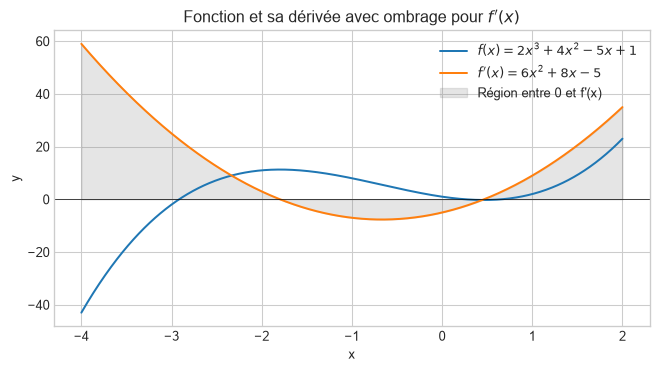

In [20]:
# 1. Définir la variable symbolique et la fonction
x = sp.Symbol('x', real=True)
f_expr = 2*x**3 + 4*x**2 - 5*x + 1

# 2. Calculer la dérivée de f
f_prime_expr = sp.diff(f_expr, x)

# 3. Convertir les expressions symboliques en fonctions Python
f = sp.lambdify(x, f_expr, 'numpy')
f_prime = sp.lambdify(x, f_prime_expr, 'numpy')

# 4. Générer une plage de valeurs x
x_vals = np.linspace(-4, 2, 1000)

# 5. Calculer f et f' sur cette plage
y_vals = f(x_vals)
y_prime_vals = f_prime(x_vals)

# 6. Préparer les chaînes LaTeX pour la légende
f_label = rf'$f(x) = {sp.latex(f_expr)}$'
f_prime_label = rf'$f^\prime(x) = {sp.latex(f_prime_expr)}$'

# 7. Tracer f et f', avec les équations dans la légende
plt.figure(figsize=(8, 4))
plt.plot(x_vals, y_vals, label=f_label)
plt.plot(x_vals, y_prime_vals, label=f_prime_label)

# 8. Colorier la région entre l'axe x et f'(x) pour tout le domaine
plt.fill_between(x_vals, y_prime_vals, 0, color='gray', alpha=0.2, interpolate=True,
                 label='Région entre 0 et f\'(x)')

# 9. Ajouter une ligne de référence, des étiquettes, une légende, etc.
plt.axhline(0, color='black', linewidth=0.5)
plt.title(rf'Fonction et sa dérivée avec ombrage pour $f^\prime(x)$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Pour les **fonctions dépourvues d’un minimum global**, la descente de
gradient peut **continuer à descendre indéfiniment**, empêchant la
convergence.

- Le premier objectif de cet exemple est d’illustrer que la descente de
  gradient est applicable à des fonctions de complexité arbitraire, à
  condition que le gradient puisse être calculé ou approximé à chaque
  itération.

- De plus, la fonction doit posséder au moins un minimum local dans
  l’intervalle d’intérêt.

## Taux d’apprentissage

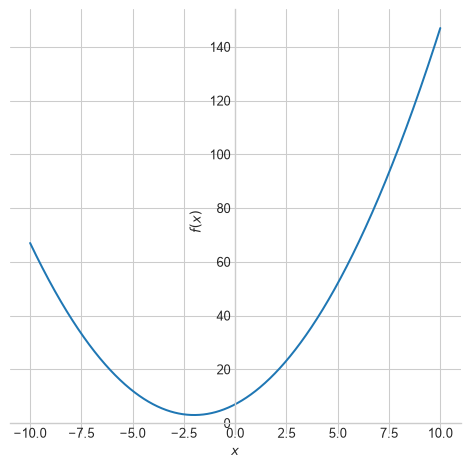

- **Petits pas**, des valeurs faibles pour $\alpha$, feront que
  l’algorithme **convergera lentement**.
- **Grands pas** peuvent amener l’algorithme à **diverger**.
- Remarquez comment l’algorithme **ralentit** naturellement en
  approchant d’un minimum.

## Taux d’apprentissage

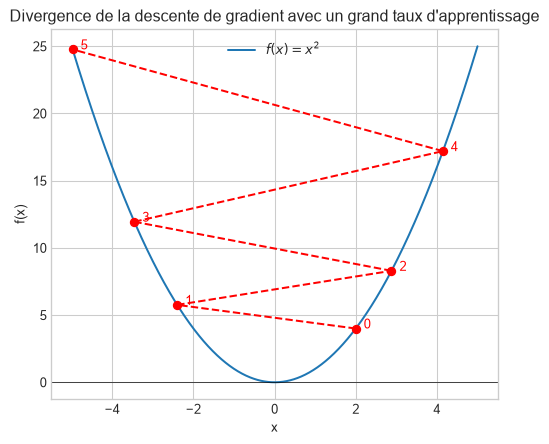

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2

def grad_f(x):
    return 2*x

# Estimation initiale, taux d'apprentissage et nombre d'étapes de descente de gradient
x_current = 2.0
learning_rate = 1.1  # Trop grand => divergence
num_iterations = 5   # Nous ferons cinq mises à jour

# Stocker chaque valeur de x dans une liste (trajectoire) pour l'affichage
trajectory = [x_current]

# Effectuer la descente de gradient
for _ in range(num_iterations):
    g = grad_f(x_current)
    x_current = x_current - learning_rate * g
    trajectory.append(x_current)

# Préparer les données pour l'affichage
x_vals = np.linspace(-5, 5, 1000)
y_vals = f(x_vals)

# Tracer la fonction f(x)
plt.figure(figsize=(6, 5))
plt.plot(x_vals, y_vals, label=r"$f(x) = x^2$")
plt.axhline(0, color='black', linewidth=0.5)

# Tracer la trajectoire, en étiquetant chaque itération
for i, x_t in enumerate(trajectory):
    y_t = f(x_t)
    # Tracer le point
    plt.plot(x_t, y_t, 'ro')
    # Étiqueter le numéro d'itération
    plt.text(x_t, y_t, f"  {i}", color='red')
    # Connecter les points consécutifs
    if i > 0:
        x_prev = trajectory[i - 1]
        y_prev = f(x_prev)
        plt.plot([x_prev, x_t], [y_prev, y_t], 'r--')

# Finitions
plt.title("Divergence de la descente de gradient avec un grand taux d'apprentissage")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

## Descente de gradient par lot (*batch*)

- Pour être plus précis, cet algorithme est connu sous le nom de
  **descente de gradient par lot** car à chaque itération, il traite le
  “lot entier” d’exemples d’apprentissage.

. . .

- La littérature suggère que l’algorithme pourrait mettre plus de temps
  à converger si les attributs sont sur des échelles différentes.

## Descente de gradient par lot - inconvénient

- L’algorithme de **descente de gradient par lot** devient très **lent**
  à mesure que le **nombre d’exemples d’apprentissage augmente**.

. . .

- Cela est dû au fait que **toutes** les données d’apprentissage sont
  vues à **chaque itération**. L’algorithme est généralement exécuté
  pour un nombre fixe d’itérations, disons 1000.

## Descente de gradient stochastique

L’algorithme de **descente de gradient stochastique** sélectionne
aléatoirement **un** exemple d’apprentissage pour calculer son gradient.

``` python
epochs = 10
for epoch in range(epochs):
    for i in range(N):
        selection = np.random.randint(N)
        # Calcul du gradient à l'aide de la sélection
        # Mise à jour des paramètres
```

- Cela lui permet de fonctionner avec de grands ensembles
  d’apprentissage.
- Sa trajectoire n’est pas aussi régulière que l’algorithme par lot.
- En raison de sa trajectoire accidentée, il est souvent meilleur pour
  trouver les **minima globaux** par rapport à l’algorithme par lot.
- Sa trajectoire accidentée le fait rebondir autour des minima locaux.

Pour atténuer le problème d’oscillation autour des minima locaux, il est
conseillé de réduire progressivement le taux d’apprentissage à mesure
que le nombre d’époques augmente. Cette technique, connue sous le nom de
**planning d’apprentissage**, aide à atteindre une convergence plus
stable.

Il est important que les exemples soient **sélectionnés aléatoirement**
ou **mélangés** avant d’exécuter l’algorithme pour s’assurer que
l’algorithme converge vers les minima globaux.

## Descente de gradient par mini-lots

- À chaque étape, plutôt que de sélectionner un exemple d’apprentissage
  comme le fait la SGD, la **descente de gradient par mini-lots**
  (*mini-batch*) sélectionne aléatoirement un **petit nombre**
  d’exemples d’apprentissage pour calculer les gradients.
- Sa trajectoire est plus régulière comparée à la SGD.
- À mesure que la taille des mini-lots augmente, l’algorithme devient de
  plus en plus similaire à la descente de gradient par lot, qui utilise
  tous les exemples à chaque étape.
- Il peut profiter de l’accélération matérielle des opérations
  matricielles, en particulier avec les GPU.

La taille typique d’un mini-lot lors de l’application de la descente de
gradient stochastique (SGD) peut varier en fonction de l’application
spécifique et du jeu de données, mais les tailles courantes varient
souvent entre 32 et 512 échantillons. Voici quelques tailles de
mini-lots couramment utilisées en pratique :

1.  **Petits mini-lots** : Des tailles telles que 16, 32 ou 64 sont
    souvent utilisées lorsqu’on travaille avec des jeux de données plus
    petits ou lorsque les contraintes de mémoire sont une préoccupation.
2.  **Mini-lots moyens** : Des tailles comme 128, 256 ou 512 sont
    couramment utilisées et peuvent fournir un bon équilibre entre
    l’efficacité computationnelle et la vitesse de convergence.
3.  **Grands mini-lots** : Des tailles comme 1024, 2048 ou plus grandes
    peuvent être utilisées dans des tâches d’apprentissage automatique à
    grande échelle, surtout lorsque des ressources computationnelles
    suffisantes sont disponibles.

Le choix de la taille du mini-lot peut influencer plusieurs facteurs
tels que :

- **Vitesse d’entraînement** : Les grands mini-lots peuvent mieux
  exploiter les capacités de traitement parallèle, accélérant
  potentiellement l’entraînement.
- **Convergence** : Les petits mini-lots peuvent introduire plus de
  bruit dans l’estimation du gradient, ce qui peut parfois aider à
  échapper aux minima locaux et améliorer la généralisation.
- **Utilisation de la mémoire** : Les grands mini-lots nécessitent plus
  de mémoire, ce qui peut être un facteur limitant, surtout sur les GPU
  avec une VRAM limitée.

En fin de compte, la taille optimale du mini-lot est spécifique à la
tâche et est souvent déterminée empiriquement par expérimentation.

## Visualisation rapide

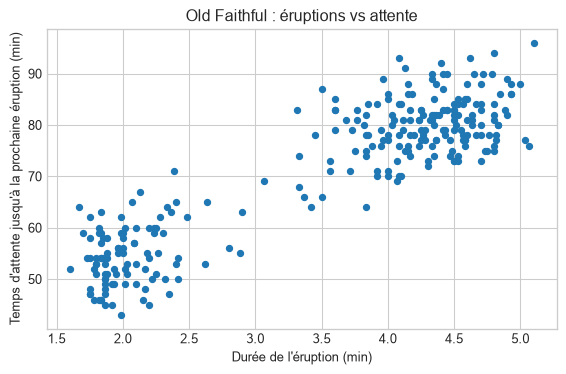

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df["eruptions"], df["waiting"], s=20)
plt.xlabel("Durée de l'éruption (min)")
plt.ylabel("Temps d'attente jusqu'à la prochaine éruption (min)")
plt.title("Old Faithful : éruptions vs attente")
plt.tight_layout()
plt.show()

## Stochastique, mini-lots, lot

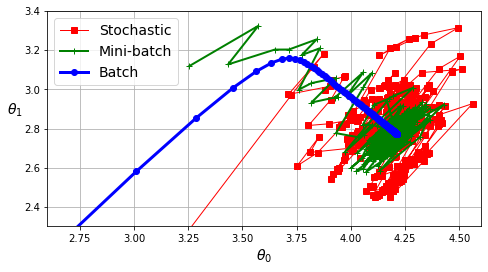

**Attribution:** Géron (2022), Figure 4.10,
[04_training_linear_models.ipynb](https://github.com/ageron/handson-ml3/blob/main/04_training_linear_models.ipynb)

## Résumé

- La **descente de gradient par lot** est intrinsèquement **lente** et
  impraticable pour de grands ensembles de données nécessitant une prise
  en charge **hors mémoire**, bien qu’elle soit capable de gérer un
  nombre substantiel d’attributs.

- La **descente de gradient stochastique** est **rapide** et bien
  adaptée pour traiter un grand volume d’exemples de manière efficace.

- La **descente de gradient par mini-lots** combine les avantages des
  méthodes par lot et stochastiques ; elle est **rapide**, capable de
  gérer de grands ensembles de données, et tire parti de l’accélération
  matérielle, en particulier avec les GPU.

Les trois sont implémentées par `SGDRegressor` dans `Scikit-Learn`.

## Optimisation et réseaux profonds

Nous allons brièvement revisiter le sujet en discutant des **réseaux de
neurones artificiels profonds**, pour lesquels il existe des
**algorithmes d’optimisation spécialisés**.

- Optimisation par Momentum
- Gradient Acceleré de Nesterov
- AdaGrad
- RMSProp
- Adam et Nadam

## Dernier mot

- L’optimisation est un sujet vaste. D’autres algorithmes existent et
  sont utilisés dans d’autres contextes.
- Parmi eux :
  - L’optimisation par essaims particulaires (PSO), les algorithmes
    génétiques (GA), et les algorithmes de colonie d’abeilles
    artificielles (ABC).

# Prologue

## Régression linéaire - résumé

- Un **modèle linéaire** suppose que la valeur de l’étiquette,
  $\hat{y_i}$, peut être exprimée comme une **combinaison linéaire** des
  valeurs des attributs, $x_i^{(j)}$ : $$
  \hat{y_i} = h(x_i) = \theta_0 + \theta_1 x_i^{(1)} + \theta_2 x_i^{(2)} + \ldots + \theta_D x_i^{(D)}
  $$

- L’**écart moyen quadratique (MSE)** est : $$
  \frac{1}{N}\sum_1^N [h(x_i) - y_i]^2
  $$

- La **descente de gradient par lot**, **stochastique**, ou **par
  mini-lots** peut être utilisée pour trouver les valeurs “optimales”
  des poids, $\theta_j$ pour $j \in 0, 1, \ldots, D$.

- Le résultat est un **régresseur**, une fonction qui peut être utilisée
  pour prédire la valeur $y$ (l’étiquette) pour un exemple non vu $x$.

## Andrew Ng

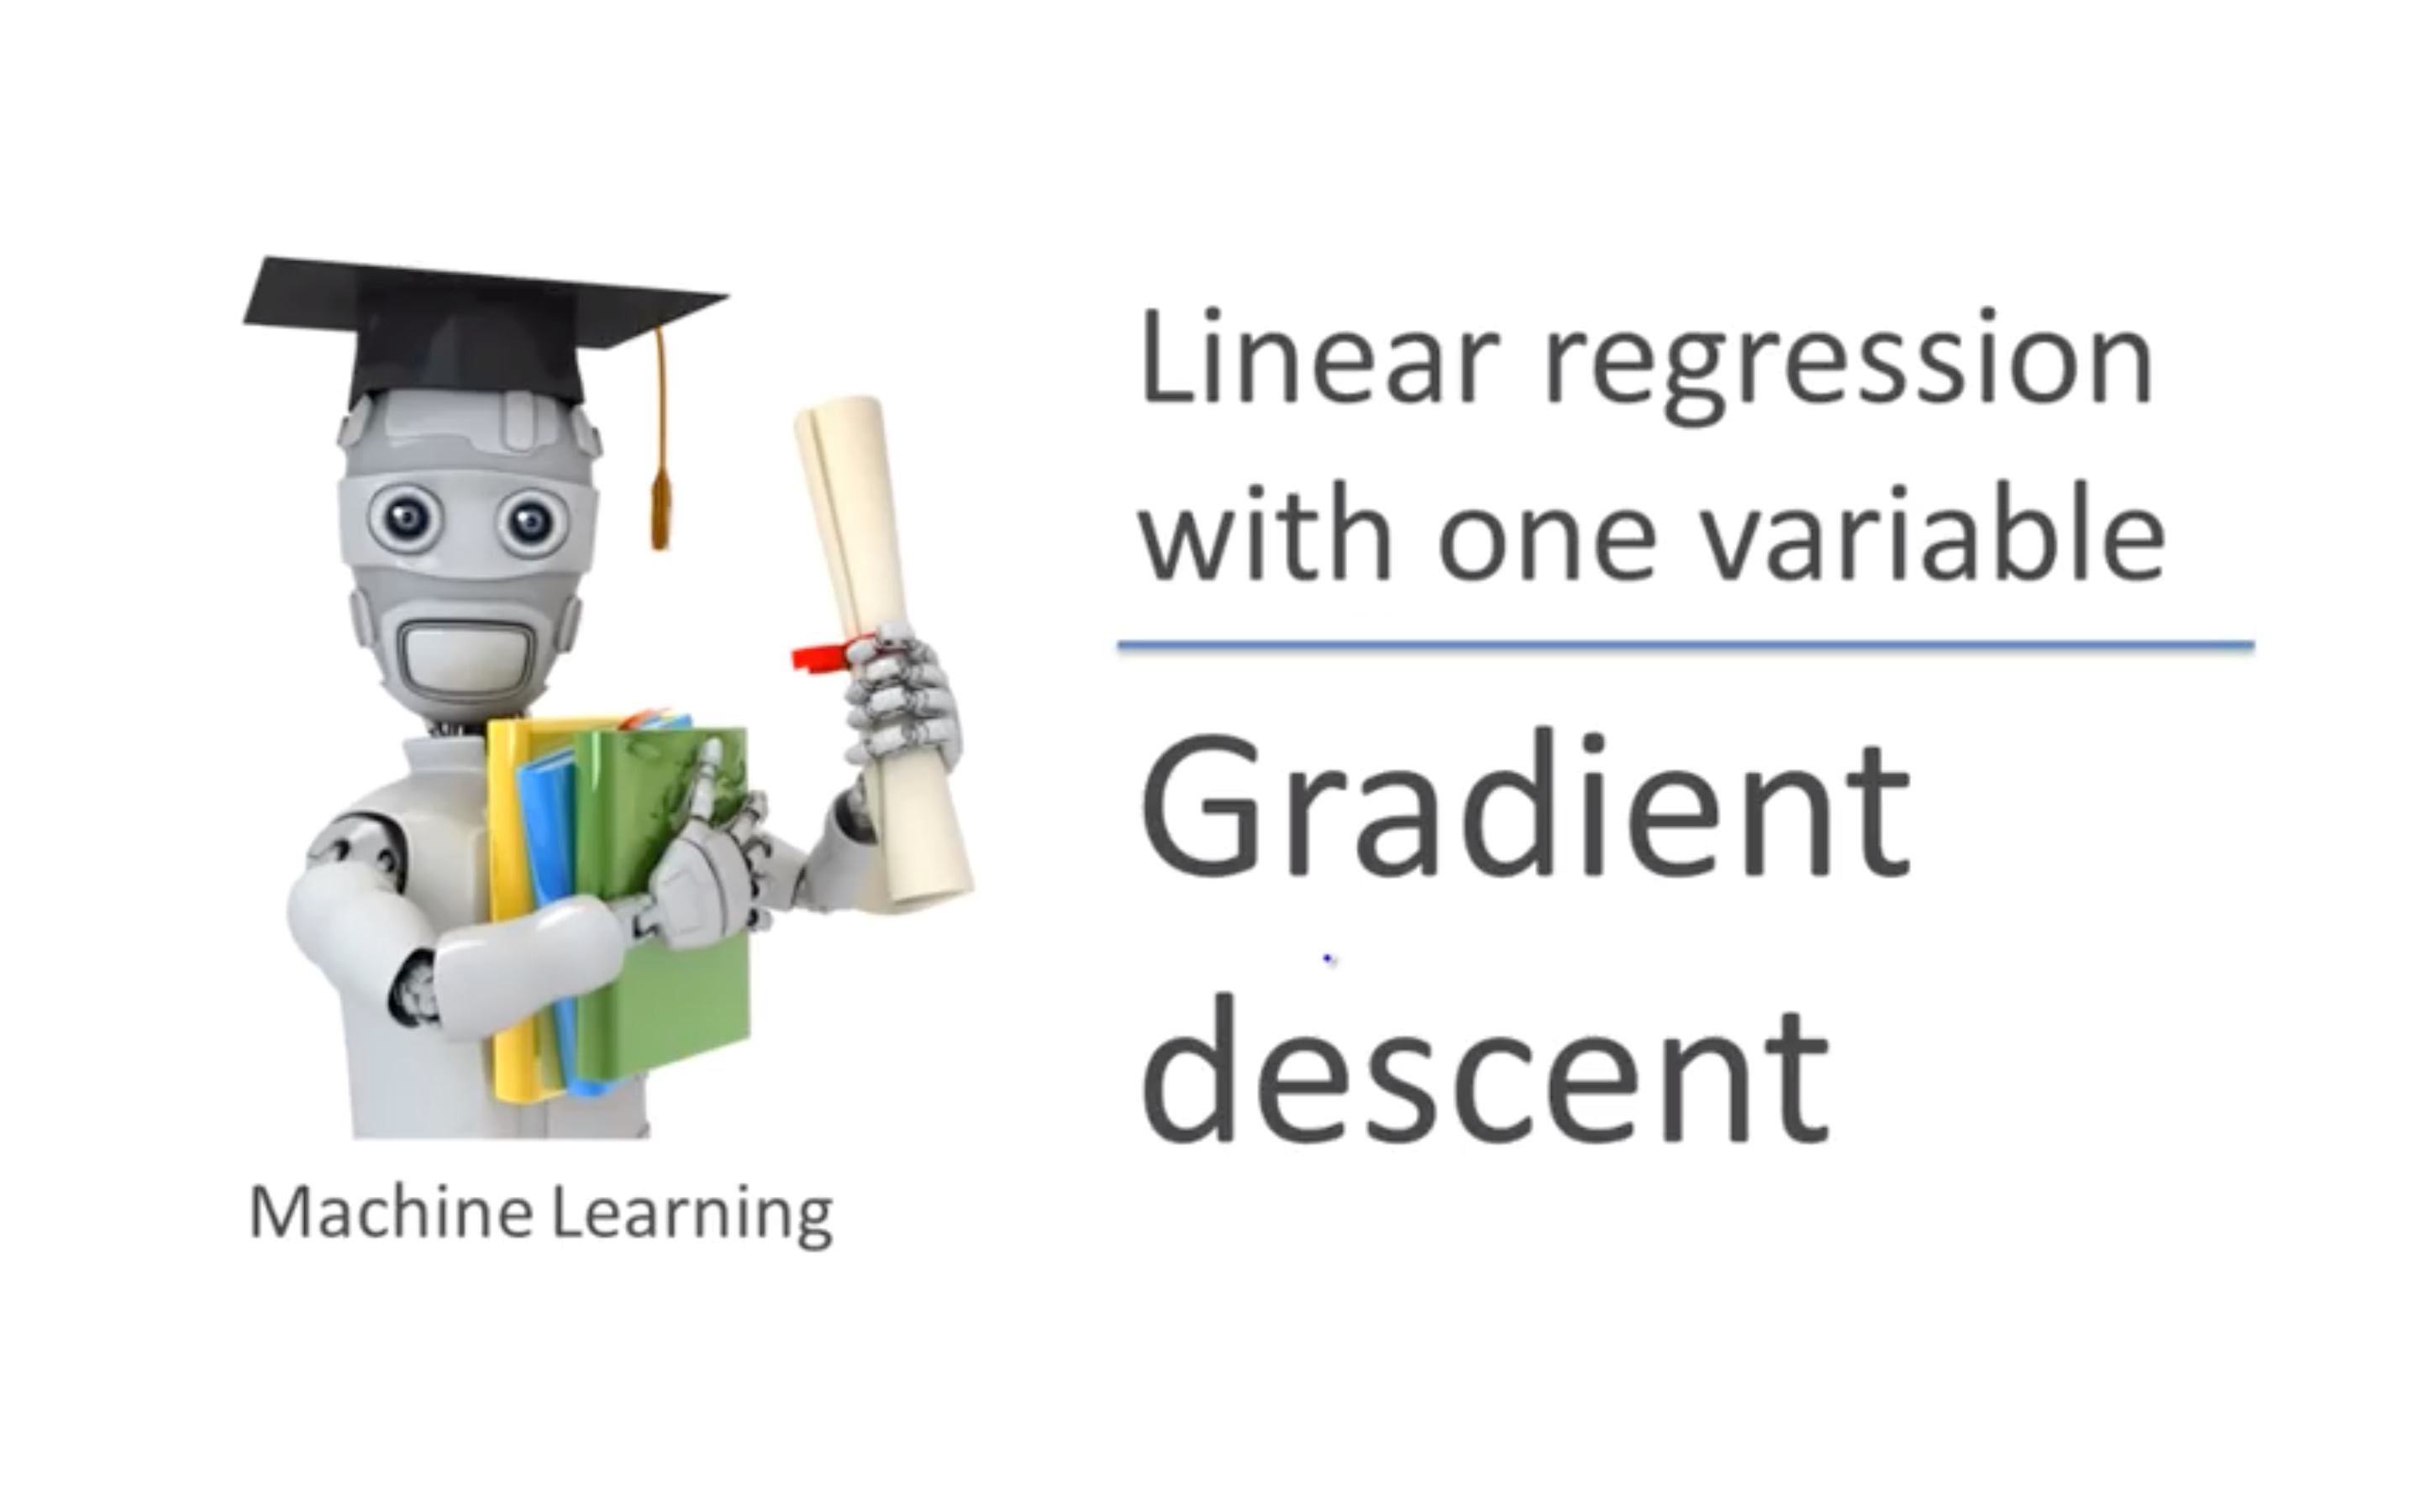

- [Gradient Descent
  (Math)](https://youtu.be/sOou4izGINg?si=_Fz1V1tbGk8usJR0) <br/> (11:30
  m)
- [Intuition](https://youtu.be/DS83GeqWQqs?si=kOfDpHT_4t8hl_YL)
  <br/>(11:51 m)
- [Linear
  Regression](https://www.youtube.com/watch?v=nOMy9LIcIkI&list=PLb0Gp98iu3OyY9zWJfSMq26nmkNKztNhA&index=6)
  <br/>(10:20 m)
- [ML-005 \| Stanford \| Andrew
  Ng](https://www.youtube.com/playlist?list=PLoR5VjrKytrCv-Vxnhp5UyS1UjZsXP0Kj)<br/>
  (19 videos)

[Andrew Ng](https://www.andrewng.org) présente l’algorithme de descente
de gradient en utilisant une régression linéaire avec une variable.

Andrew Ng est le fondateur de
[DeepLearning.AI](https://www.deeplearning.ai/), fondateur et PDG de
[Landing AI](https://landing.ai/), partenaire général chez [AI
Fund](https://aifund.ai/), président et cofondateur de
[Coursera](https://www.coursera.org/) et professeur au département
d’informatique de l’Université de Stanford.

Ng a également été cofondateur et responsable de [Google
Brain](https://en.wikipedia.org/wiki/Google_Brain "Google Brain") et a
été l’ancien scientifique en chef chez
[Baidu](https://en.wikipedia.org/wiki/Baidu "Baidu").

## Herman Kamper

<https://www.youtube.com/watch?v=BlnLoqn3ZBo&list=PLmZlBIcArwhOr0ysO1Hg4Wfoww0dZnHz4>

# Mathématiques

## 3Blue1Brown

- [Essence de **l’algèbre
  linéaire**](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab)
  - Une série de 16 vidéos (10 à 15 minutes par vidéo) offrant “une
    compréhension géométrique des matrices, déterminants, valeurs
    propres et plus encore.”
    - 6 662 732 vues au 30 septembre 2019.
- [Essence du
  **calcul**](https://www.youtube.com/playlist?list=PLZHQObOWTQDMsr9K-rj53DwVRMYO3t5Yr)
  - Une série de 12 vidéos (15 à 20 minutes par vidéo) : “L’objectif ici
    est de faire en sorte que le calcul apparaisse comme quelque chose
    que vous auriez pu découvrir vous-même.”
    - 2 309 726 vues au 30 septembre 2019.

## Prochain cours

- Régression logistique

# Annexe

## Régression linéaire

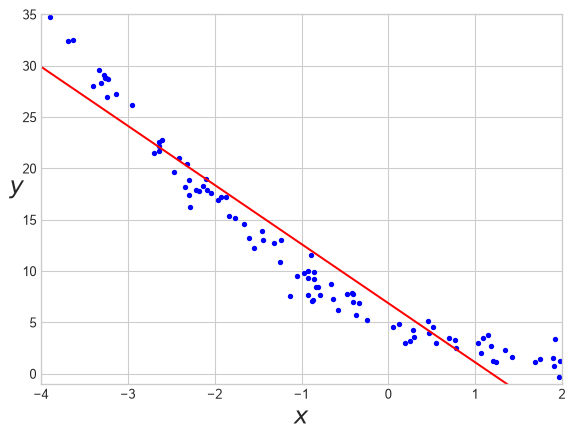

In [25]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

Ici, nous examinons un modèle simple impliquant une seule variable.

## Code source

In [26]:
import numpy as np

X = 6 * np.random.rand(100, 1) - 4
y = X ** 2 - 4 * X + 5 + np.random.randn(100, 1)

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

X_new = np.array([[-4], [2]])
y_pred = lin_reg.predict(X_new)

Cet écran contient une anomalie. Pouvez-vous l’identifier ?

Les données ont été générées à partir d’un modèle quadratique,
$x^2 - 4x + 5$, avec du bruit gaussien ajouté pour rendre les données
synthétiques plus réalistes.

Cet exemple illustre que, dans la pratique, nous avons souvent une
connaissance limitée du modèle sous-jacent qui a généré les données.

Malgré cette incertitude, nous faisons des hypothèses—dans ce cas, en
supposant la linéarité—lors de la construction de nos modèles.

Plus tard, nous nous référerons à cela comme **biais** (distinct du
paramètre de biais dans notre modèle de régression). Le biais et la
variance influencent tous deux la performance de nos modèles.

## Interactions GPT 4o (2024-09-14)

**Utilisateur** : Expliquez le code sur l’écran précédent ligne par
ligne.

. . .

**IA** : Certainement ! Voici une explication ligne par ligne du code
fourni :

In [27]:
import numpy as np

- **Explication** : Cette ligne importe la bibliothèque NumPy, qui est
  un paquet fondamental pour les calculs numériques en Python. Elle est
  couramment utilisée pour travailler avec des tableaux et des matrices,
  ainsi que pour effectuer diverses opérations mathématiques.

In [28]:
X = 6 * np.random.rand(100, 1) - 4

- **Explication** : Cette ligne génère un tableau NumPy `X` contenant
  100 lignes et 1 colonne de nombres aléatoires. La fonction
  `np.random.rand(100, 1)` génère des nombres aléatoires uniformément
  distribués entre 0 et 1. La multiplication par 6 ajuste ces nombres à
  la plage \[0, 6), et la soustraction de 4 déplace la plage à \[-4, 2).

In [29]:
y = X ** 2 - 4 * X + 5 + np.random.randn(100, 1)

- **Explication** : Cette ligne génère la variable cible `y` basée sur
  une équation quadratique avec du bruit ajouté. Plus précisément :

  - `X ** 2` calcule le carré de chaque élément de `X`.
  - `- 4 * X` soustrait quatre fois chaque élément de `X`.
  - `+ 5` ajoute une constante de 5.
  - `+ np.random.randn(100, 1)` ajoute du bruit gaussien avec une
    moyenne de 0 et un écart-type de 1 à chaque élément, rendant les
    données plus réalistes en introduisant une certaine variabilité.

In [30]:
from sklearn.linear_model import LinearRegression

- **Explication** : Cette ligne importe la classe `LinearRegression` du
  module `sklearn.linear_model`, qui fait partie de la bibliothèque
  Scikit-Learn. Scikit-Learn est largement utilisée pour l’apprentissage
  automatique en Python.

In [31]:
lin_reg = LinearRegression()

- **Explication** : Cette ligne crée une instance de la classe
  `LinearRegression` et l’assigne à la variable `lin_reg`. Cet objet
  sera utilisé pour ajuster le modèle de régression linéaire aux
  données.

In [32]:
lin_reg.fit(X, y)

- **Explication** : Cette ligne ajuste le modèle de régression linéaire
  aux données en trouvant la meilleure ligne passant par les points
  `(X, y)`. La méthode `fit` entraîne le modèle en utilisant les
  attributs fournis `X` et la variable cible `y`.

In [33]:
X_new = np.array([[-4], [2]])

- **Explication** : Cette ligne crée un nouveau tableau NumPy `X_new`
  avec deux valeurs : -4 et 2. Ces valeurs représentent de nouveaux
  points de données pour lesquels nous voulons prédire la variable cible
  en utilisant le modèle entraîné.

In [34]:
y_pred = lin_reg.predict(X_new)

- **Explication** : Cette ligne utilise le modèle de régression linéaire
  entraîné pour prédire la variable cible `y_pred` pour les nouveaux
  points de données dans `X_new`. La méthode `predict` renvoie les
  valeurs prédites basées sur le modèle ajusté.

En résumé, ce script génère des données synthétiques, ajuste un modèle
de régression linéaire à ces données, puis utilise le modèle pour faire
des prédictions sur de nouveaux points de données.

## Source code (continued)

In [35]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt

def save_fig(fig_id, tight_layout=True, fig_extension="pdf", resolution=300):
    path = os.path.join(fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Source code (continued)

In [36]:
plt.plot(X, y, "b.")
plt.plot(X_new, y_pred, "r-")
plt.xlabel("$x$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-4, 2, -1, 35])
save_fig("regression_linear-01")
plt.show()

## References

Azzalini, A., et A. W. Bowman. 1990. « A Look at Some Data on the Old
Faithful Geyser ». *Journal of the Royal Statistical Society Series C:
Applied Statistics* 39 (3): 357‑65. <https://doi.org/10.2307/2347385>.

Géron, Aurélien. 2022. *Hands-on Machine Learning with Scikit-Learn,
Keras, and TensorFlow*. 3ᵉ éd. O’Reilly Media, Inc.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

Stanton, Jeffrey M. 2001. « Galton, Pearson, and the Peas: A Brief
History of Linear Regression for Statistics Instructors ». *Journal of
Statistics Education* 9 (3).
<https://doi.org/10.1080/10691898.2001.11910537>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa